# PM2.5 Forecasting — Phnom Penh, 48-Hour Ahead

> 


## 1. Load Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import math
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    print("XGBoost not available:", e)

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    TENSORFLOW_AVAILABLE = True
except Exception as e:
    TENSORFLOW_AVAILABLE = False
    print("TensorFlow not available:", e)

pd.set_option("display.max_columns", 100)


## 2. Load Data and Filter Phnom Penh

In [2]:
DATA_PATH = "cambo_air_quality.csv"
CITY = "Phnom Penh"
H = 48  # prediction horizon in hours

df_all = pd.read_csv(DATA_PATH)
df_all.columns = (
    df_all.columns.str.strip().str.lower()
    .str.replace(" ", "_").str.replace(".", "_", regex=False)
)
df_all["timestamp"] = pd.to_datetime(df_all["timestamp"], errors="coerce")
df_all = df_all.dropna(subset=["timestamp"])

df = (
    df_all[df_all["city"].str.lower() == CITY.lower()]
    .sort_values("timestamp")
    .reset_index(drop=True)
)

if df.empty:
    raise ValueError(f"'{CITY}' not found. Available: {sorted(df_all['city'].unique())}")

print(f"City       : {CITY}")
print(f"Rows       : {len(df):,}")
print(f"Date range : {df['timestamp'].min()} → {df['timestamp'].max()}")
df.head()

City       : Phnom Penh
Rows       : 28,825
Date range : 2023-01-01 00:00:00 → 2026-04-16 00:00:00


,timestamp,city,lat,lon,aqi,pollution_level,pollution_class,temp,humidity,rain,wind_speed,wind_dir,pressure,cloud,pm2_5,pm10,co,no2,o3,so2
0,2023-01-01 00:00:00,Phnom Penh,11.5564,104.9282,51,Moderate,1,22.6,76,0.0,10.7,12,1013.5,100,10.6,15.7,653.0,4.0,78.0,1.6
1,2023-01-01 01:00:00,Phnom Penh,11.5564,104.9282,51,Moderate,1,22.5,78,0.0,12.3,15,1013.2,100,10.9,16.0,614.0,3.2,76.0,1.6
2,2023-01-01 02:00:00,Phnom Penh,11.5564,104.9282,51,Moderate,1,22.0,80,0.0,10.9,9,1012.8,100,11.6,17.1,596.0,2.7,73.0,1.6
3,2023-01-01 03:00:00,Phnom Penh,11.5564,104.9282,50,Good,0,21.7,81,0.0,10.5,6,1012.6,100,12.0,17.6,584.0,2.1,70.0,1.6
4,2023-01-01 04:00:00,Phnom Penh,11.5564,104.9282,50,Good,0,21.3,82,0.0,11.2,2,1012.4,100,11.7,17.1,586.0,2.0,66.0,1.5


## 3. Explore the Data

## Descriptive statistics for pollutant and weather variables

In [3]:

# This table helps us understand the data before building the prediction model.

desc_cols = [
    c for c in [
        "pm2_5", "pm10", "temp", "humidity", "rain", 
        "wind_speed", "wind_dir", "pressure", "cloud"
    ]
    if c in df.columns
]

# Main descriptive statistics
stats = df[desc_cols].describe().T
stats["median"] = df[desc_cols].median()
stats["q1"] = df[desc_cols].quantile(0.25)
stats["q3"] = df[desc_cols].quantile(0.75)
stats["iqr"] = stats["q3"] - stats["q1"]
stats["missing"] = df[desc_cols].isna().sum()
stats["missing_%"] = (df[desc_cols].isna().mean() * 100)
stats["skewness"] = df[desc_cols].skew()

stats = stats[[
    "count", "mean", "median", "std", "min", "q1", 
    "q3", "max", "iqr", "missing", "missing_%", "skewness"
]]

display(stats.round(2))

# PM2.5 category summary using common concentration ranges
pm25_bins = [-np.inf, 12, 35, 55, 150, np.inf]
pm25_labels = [
    "Good (≤12)",
    "Moderate (12–35)",
    "Unhealthy for Sensitive (35–55)",
    "Unhealthy (55–150)",
    "Very Unhealthy (>150)"
]

pm25_category = pd.cut(df["pm2_5"], bins=pm25_bins, labels=pm25_labels)
pm25_summary = (
    pm25_category.value_counts()
    .reindex(pm25_labels)
    .fillna(0)
    .astype(int)
    .to_frame("count")
)
pm25_summary["percentage"] = (pm25_summary["count"] / len(df) * 100).round(2)

display(pm25_summary)

# Monthly descriptive statistics for PM2.5
month_order = ["January", "February", "March", "April", "May", "June", 
               "July", "August", "September", "October", "November", "December"]
monthly_pm25_stats = df.assign(
    month=pd.Categorical(df["timestamp"].dt.month_name(), categories=month_order, ordered=True)
).groupby("month")["pm2_5"].agg(["count", "mean", "median", "std", "min", "max"])

display(monthly_pm25_stats.dropna(how="all").round(2))


,count,mean,median,std,min,q1,q3,max,iqr,missing,missing_%,skewness
pm2_5,28825.0,20.16,15.4,15.17,0.4,9.5,26.4,154.6,16.9,0,0.0,1.87
pm10,28825.0,25.54,21.0,17.82,0.4,12.4,34.1,159.3,21.7,0,0.0,1.63
temp,28825.0,27.97,27.4,3.09,18.4,25.7,30.1,39.3,4.4,0,0.0,0.50
humidity,28825.0,74.94,77.0,16.35,22.0,64.0,89.0,100.0,25.0,0,0.0,-0.54
rain,28825.0,0.22,0.0,1.00,0.0,0.0,0.0,26.0,0.0,0,0.0,8.66
wind_speed,28825.0,8.95,8.6,4.31,0.0,5.7,11.6,28.6,5.9,0,0.0,0.56
wind_dir,28825.0,161.92,175.0,95.18,1.0,74.0,223.0,360.0,149.0,0,0.0,0.03
pressure,28825.0,1008.02,1007.9,2.76,998.1,1006.1,1009.8,1018.3,3.7,0,0.0,0.17
cloud,28825.0,74.95,98.0,35.34,0.0,50.0,100.0,100.0,50.0,0,0.0,-1.09


,count,percentage
pm2_5,,
Good (≤12),10615,36.83
Moderate (12–35),14140,49.05
Unhealthy for Sensitive (35–55),3032,10.52
Unhealthy (55–150),1036,3.59
Very Unhealthy (>150),2,0.01


,count,mean,median,std,min,max
month,,,,,,
January,2976,22.08,16.9,14.26,0.4,100.4
February,2712,27.92,26.7,13.98,4.0,98.0
March,2976,33.79,29.0,18.55,5.3,154.6
April,2521,33.89,30.0,18.90,4.6,129.5
May,2232,25.48,21.8,14.13,4.7,113.2
June,2160,16.51,12.7,11.87,2.6,89.6
July,2232,10.47,9.3,6.19,0.8,49.5
August,2232,10.38,9.6,4.85,2.2,31.7
September,2160,10.79,9.3,6.44,1.3,40.4


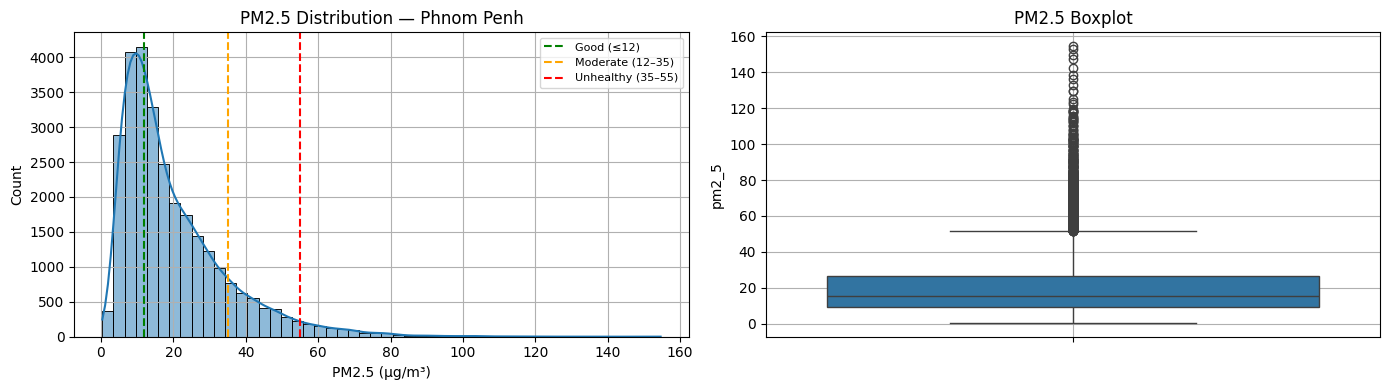

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["pm2_5"], bins=50, kde=True, ax=axes[0])
axes[0].axvline(12, color="green", linestyle="--", label="Good (≤12)")
axes[0].axvline(35, color="orange", linestyle="--", label="Moderate (12–35)")
axes[0].axvline(55, color="red", linestyle="--", label="Unhealthy (35–55)")
axes[0].set_title(f"PM2.5 Distribution — {CITY}")
axes[0].set_xlabel("PM2.5 (µg/m³)")
axes[0].legend(fontsize=8)
axes[0].grid(True)

sns.boxplot(y=df["pm2_5"], ax=axes[1])
axes[1].set_title("PM2.5 Boxplot")
axes[1].grid(True)

plt.tight_layout()
plt.show()

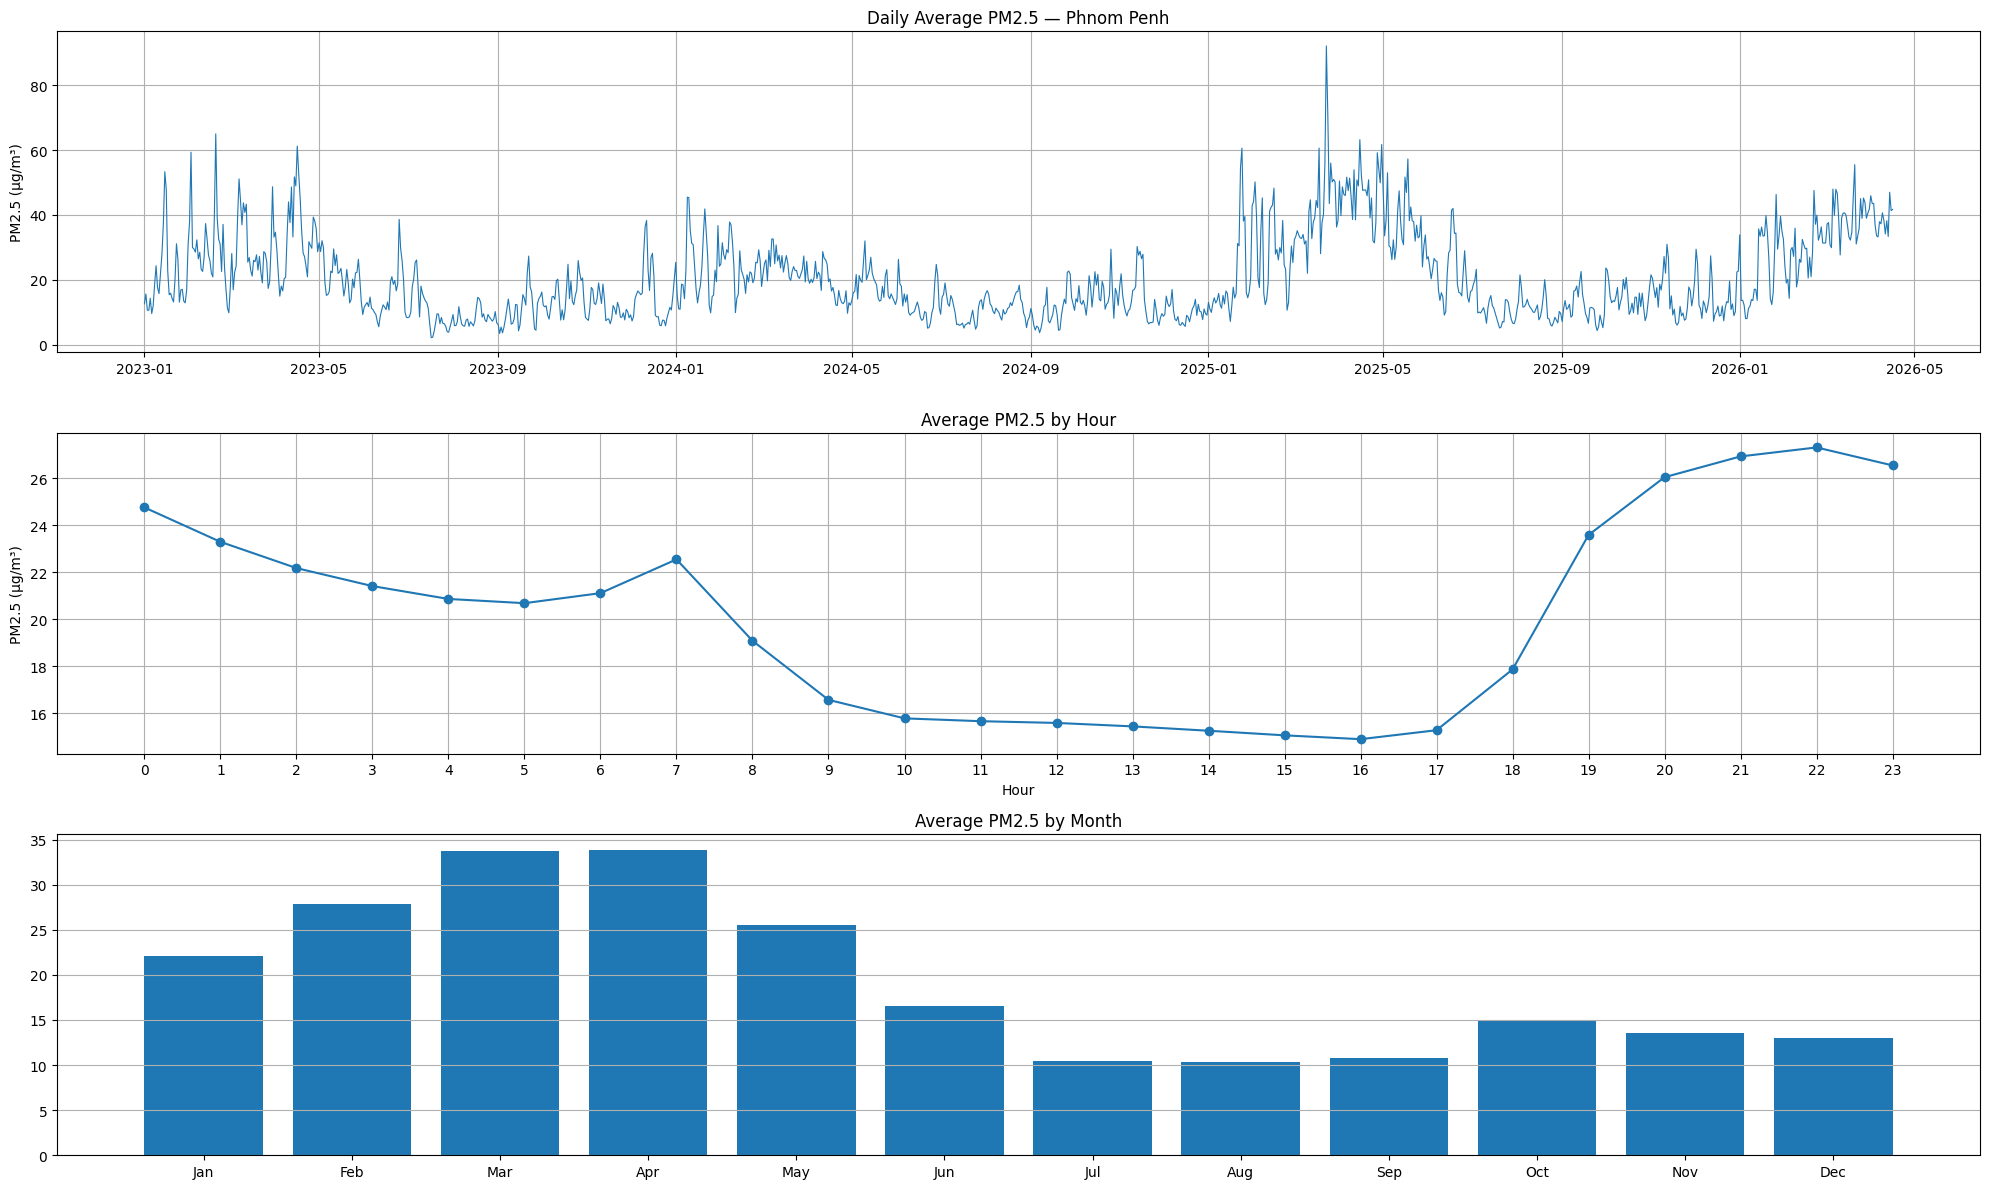

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(20, 12))

daily = df.set_index("timestamp")["pm2_5"].resample("D").mean()
axes[0].plot(daily.index, daily.values, linewidth=0.8)
axes[0].set_title(f"Daily Average PM2.5 — {CITY}")
axes[0].set_ylabel("PM2.5 (µg/m³)")
axes[0].grid(True)

hourly = df.groupby(df["timestamp"].dt.hour)["pm2_5"].mean()
axes[1].plot(hourly.index, hourly.values, marker="o")
axes[1].set_title("Average PM2.5 by Hour")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("PM2.5 (µg/m³)")
axes[1].set_xticks(range(24))
axes[1].grid(True)

monthly = df.groupby(df["timestamp"].dt.month)["pm2_5"].mean()
axes[2].bar(monthly.index, monthly.values)
axes[2].set_title("Average PM2.5 by Month")
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
axes[2].grid(axis="y")

plt.tight_layout()
plt.show()

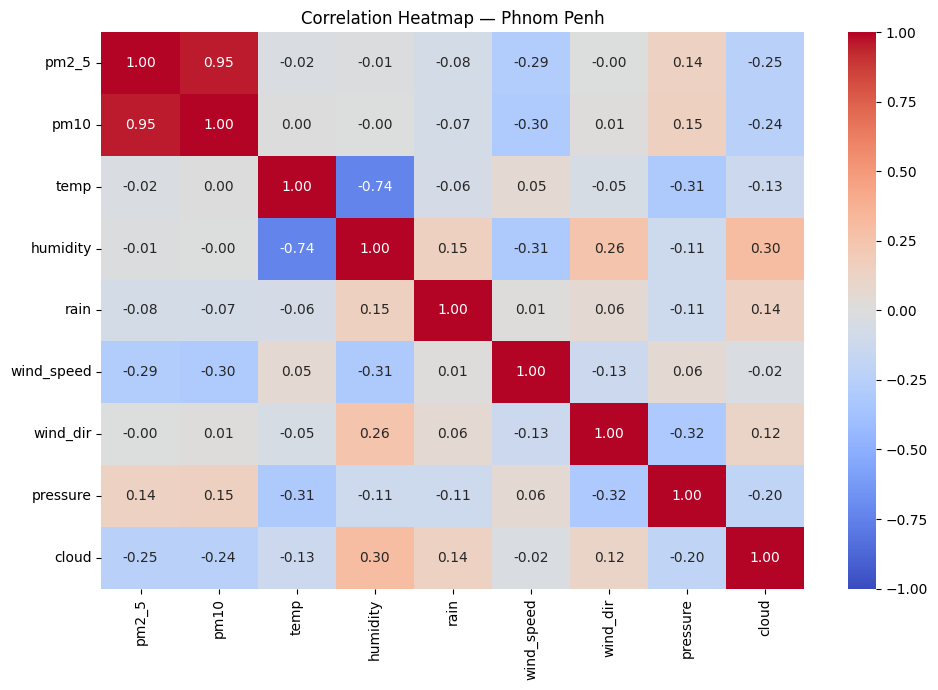

In [6]:
meteo_cols_raw = ["temp", "humidity", "rain", "wind_speed", "wind_dir", "pressure", "cloud"]
numeric_cols = ["pm2_5", "pm10"] + meteo_cols_raw

plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title(f"Correlation Heatmap — {CITY}")
plt.tight_layout()
plt.show()

## 4. Feature Engineering 

### How it works 

**Target** = `pm2_5` at each row — no shift. This is the value we want to predict.

**All features** are shifted **backward** by at least 48 hours. This ensures every feature was already known at prediction time (48 hours before the target).




In [5]:
feat = df.copy()

# Cap outliers at 99th percentile
cap_pm25 = feat["pm2_5"].quantile(0.99)
cap_pm10 = feat["pm10"].quantile(0.99)
feat["pm2_5"] = feat["pm2_5"].clip(upper=cap_pm25)
feat["pm10"]  = feat["pm10"].clip(upper=cap_pm10)
print(f"PM2.5 capped at {cap_pm25:.1f} | PM10 capped at {cap_pm10:.1f}")


target_col = "pm2_5"   # no shift — this is what we predict

# CYCLIC TIME ENCODING                                     
# Based on the TARGET row's timestamp                       
# (The time we are predicting FOR)                          

feat["hour"]      = feat["timestamp"].dt.hour
feat["month"]     = feat["timestamp"].dt.month
feat["dayofweek"] = feat["timestamp"].dt.dayofweek

feat["hour_sin"]  = np.sin(2 * np.pi * feat["hour"] / 24)
feat["hour_cos"]  = np.cos(2 * np.pi * feat["hour"] / 24)
feat["month_sin"] = np.sin(2 * np.pi * (feat["month"] - 1) / 12)
feat["month_cos"] = np.cos(2 * np.pi * (feat["month"] - 1) / 12)
feat["dow_sin"]   = np.sin(2 * np.pi * feat["dayofweek"] / 7)
feat["dow_cos"]   = np.cos(2 * np.pi * feat["dayofweek"] / 7)
feat["is_weekend"] = feat["dayofweek"].isin([5, 6]).astype(int)


#  RUSH HOUR INDICATOR                     
#  Morning rush: 7–9 AM, Evening rush: 5–7 PM               
#  Traffic increases PM2.5 during these hours                

feat["is_rush_hour"] = feat["hour"].isin([7, 8, 9, 17, 18, 19]).astype(int)


#   CAMBODIAN PUBLIC HOLIDAYS               
#   Less traffic on holidays → different PM2.5 pattern        

cambodian_holidays = [
    
    (1, 1),   # International New Year
    (1, 7),   # Victory Day
    (3, 8),   # International Women's Day
    (4, 14), (4, 15), (4, 16),  # Khmer New Year
    (5, 1),   # Labour Day
    (5, 14),  # King's Birthday
    (5, 15),  # King's Birthday
    (5, 16),  # King's Birthday
    (6, 18),  # Queen's Birthday
    (9, 24),  # Constitution Day
    (10, 15), # King Father's Commemoration
    (10, 29), # Coronation Day
    (11, 9),  # Independence Day
]

feat["month_day"] = list(zip(feat["timestamp"].dt.month, feat["timestamp"].dt.day))
feat["is_holiday"] = feat["month_day"].isin(cambodian_holidays).astype(int)
feat = feat.drop(columns=["month_day"])

print(f"Holiday rows: {feat['is_holiday'].sum()}")
print(f"Rush hour rows: {feat['is_rush_hour'].sum()}")


#  PM2.5 LAG FEATURES (all shifted by H + lag)              
#  shift(H) = value at prediction time (most recent)        
#  shift(H+1) = 1 hour before prediction time               
#  All are available at prediction time                     

pm25_lags = [0, 1, 3, 6, 12, 24, 48, 72, 168]
for lag in pm25_lags:
    feat[f"pm25_lag_{lag}h"] = feat["pm2_5"].shift(H + lag)


#  PM2.5 ROLLING MEAN & STD                                 
#  Computed from prediction time backward                    
#  shift(H+1) ensures no same-hour leakage                  

for window in [3, 6, 12, 24, 48]:
    shifted = feat["pm2_5"].shift(H + 1)
    feat[f"pm25_roll_mean_{window}h"] = shifted.rolling(window).mean()
    feat[f"pm25_roll_std_{window}h"]  = shifted.rolling(window).std()


#  PM10 LAG FEATURES                                        

for lag in [0, 1, 3, 6, 12, 24, 48]:
    feat[f"pm10_lag_{lag}h"] = feat["pm10"].shift(H + lag)


#   WEATHER FEATURES — CURRENT & PAST ONLY           
#   Old: weather.shift(-48) → LEAKAGE (used future weather)  
#   New: weather.shift(H), shift(H+12), shift(H+24)          
#        = weather at prediction time, 12h ago, 24h ago      
#   All available at prediction time    
#                     
meteo_cols = ["temp", "humidity", "rain", "wind_speed", "wind_dir", "pressure", "cloud"]

for col in meteo_cols:
    feat[f"{col}_now"]      = feat[col].shift(H)       # weather right now (at prediction time)
    feat[f"{col}_lag_12h"]  = feat[col].shift(H + 12)  # weather 12 hours ago
    feat[f"{col}_lag_24h"]  = feat[col].shift(H + 24)  # weather 24 hours ago

#  INTERACTION FEATURES                                      

feat["humid_x_wind"]    = feat["humidity_now"] * feat["wind_speed_now"]
feat["temp_x_humidity"] = feat["temp_now"] * feat["humidity_now"]

# ── Assemble feature list 
feature_cols = (
    # Cyclic time + special days
    ["hour_sin", "hour_cos", "month_sin", "month_cos",
     "dow_sin", "dow_cos", "is_weekend", "is_rush_hour", "is_holiday"]
    # PM2.5 lags
    + [f"pm25_lag_{lag}h" for lag in pm25_lags]
    # PM2.5 rolling stats
    + [f"pm25_roll_mean_{w}h" for w in [3, 6, 12, 24, 48]]
    + [f"pm25_roll_std_{w}h"  for w in [3, 6, 12, 24, 48]]
    # PM10 lags
    + [f"pm10_lag_{lag}h" for lag in [0, 1, 3, 6, 12, 24, 48]]
    # Weather (current + past, NO future)
    + [f"{col}_now"     for col in meteo_cols]
    + [f"{col}_lag_12h" for col in meteo_cols]
    + [f"{col}_lag_24h" for col in meteo_cols]
    # Interactions
    + ["humid_x_wind", "temp_x_humidity"]
)

model_df = feat[["timestamp", target_col] + feature_cols].dropna().reset_index(drop=True)

print(f"\nFinal dataset : {model_df.shape}")
print(f"Features       : {len(feature_cols)}")
print(f"Target         : {target_col} (no shift)")
print(f"All shifts     : backward only (≥ {H}h)")
model_df.head()

PM2.5 capped at 72.6 | PM10 capped at 87.3
Holiday rows: 1201
Rush hour rows: 7206

Final dataset : (28609, 60)
Features       : 58
Target         : pm2_5 (no shift)
All shifts     : backward only (≥ 48h)


,timestamp,pm2_5,hour_sin,hour_cos,month_sin,month_cos,dow_sin,dow_cos,is_weekend,is_rush_hour,is_holiday,pm25_lag_0h,pm25_lag_1h,pm25_lag_3h,pm25_lag_6h,pm25_lag_12h,pm25_lag_24h,pm25_lag_48h,pm25_lag_72h,pm25_lag_168h,pm25_roll_mean_3h,pm25_roll_mean_6h,pm25_roll_mean_12h,pm25_roll_mean_24h,pm25_roll_mean_48h,pm25_roll_std_3h,pm25_roll_std_6h,pm25_roll_std_12h,pm25_roll_std_24h,pm25_roll_std_48h,pm10_lag_0h,pm10_lag_1h,pm10_lag_3h,pm10_lag_6h,pm10_lag_12h,pm10_lag_24h,pm10_lag_48h,temp_now,humidity_now,rain_now,wind_speed_now,wind_dir_now,pressure_now,cloud_now,temp_lag_12h,humidity_lag_12h,rain_lag_12h,wind_speed_lag_12h,wind_dir_lag_12h,pressure_lag_12h,cloud_lag_12h,temp_lag_24h,humidity_lag_24h,rain_lag_24h,wind_speed_lag_24h,wind_dir_lag_24h,pressure_lag_24h,cloud_lag_24h,humid_x_wind,temp_x_humidity
0,2023-01-10 00:00:00,24.7,0.000000,1.000000,0.0,1.0,0.781831,0.62349,0,0,0,17.6,17.6,16.8,9.5,11.7,8.1,16.6,10.0,10.6,17.233333,15.533333,12.758333,11.908333,10.745833,0.404145,3.033590,3.685218,3.390257,2.998649,25.6,25.6,24.4,13.6,17.2,12.3,24.4,21.6,79.0,0.0,13.3,2.0,1011.3,99.0,24.2,65.0,0.0,19.4,359.0,1011.4,100.0,22.8,82.0,0.4,18.0,357.0,1012.1,100.0,1050.7,1706.4
1,2023-01-10 01:00:00,20.5,0.258819,0.965926,0.0,1.0,0.781831,0.62349,0,0,0,17.5,17.6,17.3,15.7,11.4,7.7,13.6,10.8,10.9,17.500000,16.883333,13.250000,12.304167,10.766667,0.173205,0.767898,3.917444,3.479690,3.043328,25.4,25.6,25.1,22.8,16.8,11.7,20.1,21.1,81.0,0.0,12.2,360.0,1010.8,100.0,24.7,63.0,0.0,20.7,353.0,1010.3,100.0,22.6,80.0,0.0,19.5,356.0,1011.5,100.0,988.2,1709.1
2,2023-01-10 02:00:00,20.4,0.500000,0.866025,0.0,1.0,0.781831,0.62349,0,0,0,17.5,17.5,17.6,16.3,10.7,7.8,11.1,12.3,11.6,17.566667,17.183333,13.758333,12.712500,10.847917,0.057735,0.526941,4.049121,3.490897,3.170005,25.4,25.4,25.6,23.7,15.7,11.9,16.4,21.0,82.0,0.0,12.3,5.0,1010.1,100.0,24.1,70.0,0.0,18.1,355.0,1009.3,100.0,22.4,79.0,0.0,19.6,353.0,1010.6,100.0,1008.6,1722.0
3,2023-01-10 03:00:00,19.3,0.707107,0.707107,0.0,1.0,0.781831,0.62349,0,0,0,17.5,17.5,17.6,16.8,9.3,8.5,9.5,13.5,12.0,17.533333,17.383333,14.325000,13.116667,10.981250,0.057735,0.306050,4.058017,3.458784,3.312238,25.4,25.4,25.6,24.4,13.6,13.0,14.2,20.9,83.0,0.0,11.5,360.0,1009.4,100.0,23.4,75.0,0.8,18.4,2.0,1009.0,100.0,22.1,78.0,0.0,20.5,358.0,1010.1,100.0,954.5,1734.7
4,2023-01-10 04:00:00,17.3,0.866025,0.500000,0.0,1.0,0.781831,0.62349,0,0,0,17.5,17.5,17.5,17.3,8.3,9.1,8.8,14.3,11.7,17.500000,17.500000,15.008333,13.491667,11.147917,0.000000,0.109545,3.818248,3.424200,3.435112,25.5,25.4,25.4,25.1,12.0,14.1,13.2,20.6,85.0,0.0,10.1,356.0,1009.4,100.0,22.6,82.0,0.3,14.3,342.0,1008.8,100.0,22.0,79.0,0.0,19.8,357.0,1009.7,100.0,858.5,1751.0


## 5. Feature–Target Correlation Analysis

This chart shows how strongly each feature is connected to the target. Features with higher absolute correlation can explain more of the target variation.


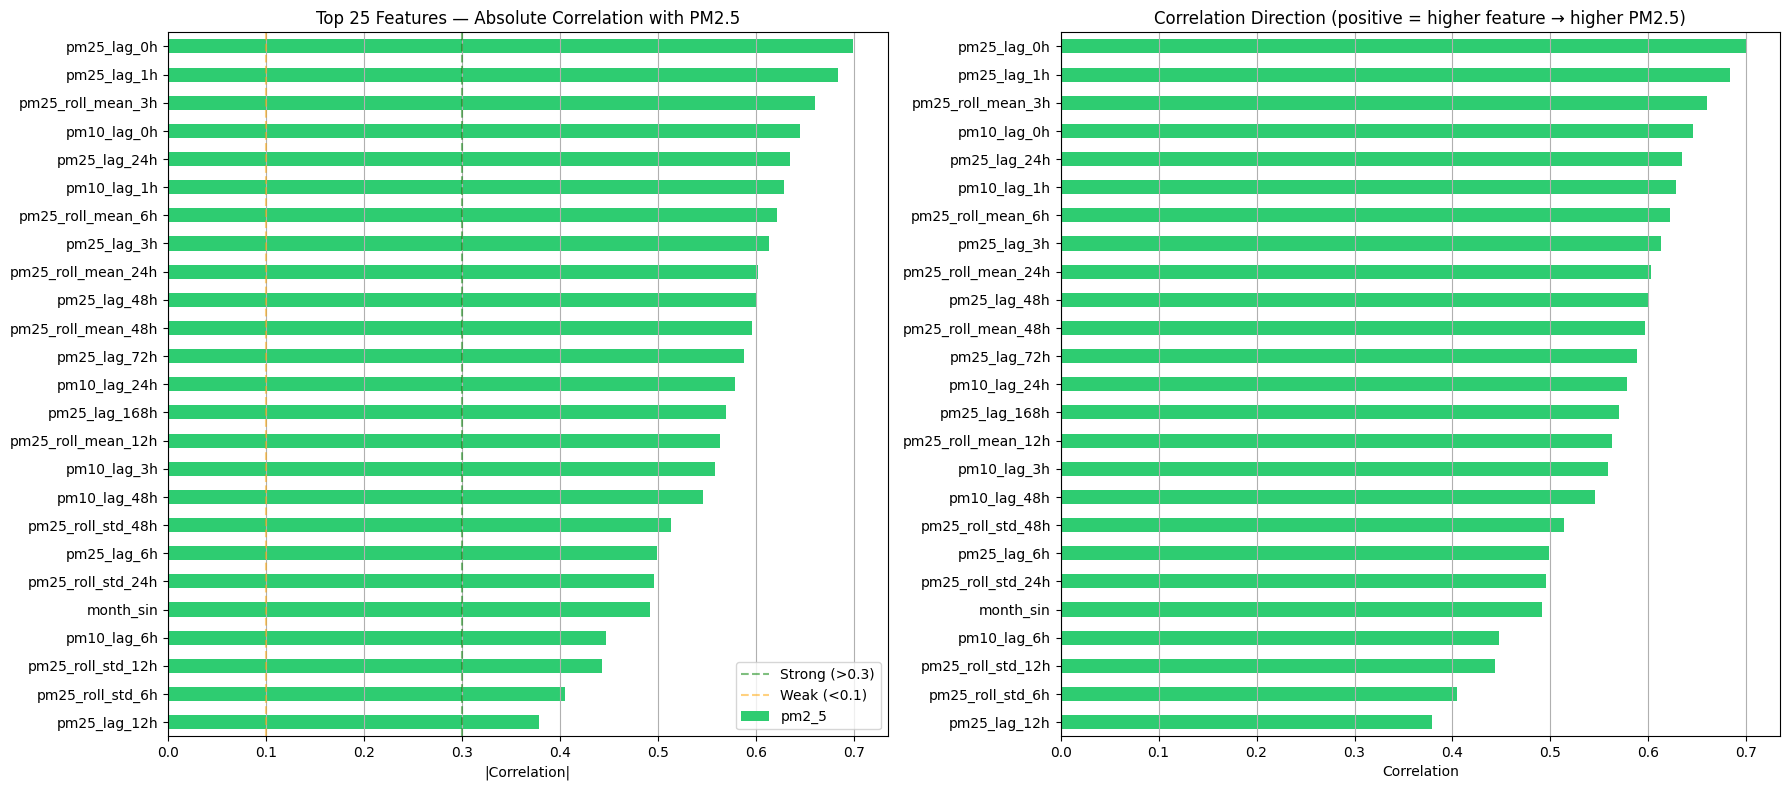


Feature-target correlation summary:
  Strong (|r| > 0.3) : 28 features
  Medium (0.1–0.3)   : 15 features
  Weak   (|r| < 0.1) : 15 features

Note: Low correlation does not always mean useless — the model can learn
non-linear relationships that simple correlation cannot capture.


In [6]:
# Compute correlation of each feature with the target
corr_with_target = model_df[feature_cols + [target_col]].corr()[target_col].drop(target_col)
corr_sorted = corr_with_target.abs().sort_values(ascending=False)

# Show top 25
top_n = min(25, len(corr_sorted))
top_features = corr_sorted.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Bar chart: absolute correlation
colors = ["#2ecc71" if v > 0.3 else "#f39c12" if v > 0.1 else "#e74c3c" for v in top_features.values]
top_features.sort_values().plot(kind="barh", ax=axes[0], color=colors[::-1])
axes[0].set_title(f"Top {top_n} Features — Absolute Correlation with PM2.5")
axes[0].set_xlabel("|Correlation|")
axes[0].axvline(0.3, color="green", linestyle="--", alpha=0.5, label="Strong (>0.3)")
axes[0].axvline(0.1, color="orange", linestyle="--", alpha=0.5, label="Weak (<0.1)")
axes[0].legend()
axes[0].grid(axis="x")

# Actual correlation (with sign)
corr_with_sign = corr_with_target[top_features.index].sort_values()
corr_with_sign.plot(kind="barh", ax=axes[1], color=["#e74c3c" if v < 0 else "#2ecc71" for v in corr_with_sign.values])
axes[1].set_title("Correlation Direction (positive = higher feature → higher PM2.5)")
axes[1].set_xlabel("Correlation")
axes[1].axvline(0, color="black", linewidth=0.5)
axes[1].grid(axis="x")

plt.tight_layout()
plt.show()

# Summary
strong = (corr_sorted > 0.3).sum()
medium = ((corr_sorted > 0.1) & (corr_sorted <= 0.3)).sum()
weak   = (corr_sorted <= 0.1).sum()
print(f"\nFeature-target correlation summary:")
print(f"  Strong (|r| > 0.3) : {strong} features")
print(f"  Medium (0.1–0.3)   : {medium} features")
print(f"  Weak   (|r| < 0.1) : {weak} features")
print(f"\nNote: Low correlation does not always mean useless — the model can learn")
print(f"non-linear relationships that simple correlation cannot capture.")

## 6. Train / Validation / Test Split (Chronological)

In [7]:
model_df = model_df.sort_values("timestamp").reset_index(drop=True)

n = len(model_df)
train_end = int(n * 0.8)
val_end   = int(n * 0.9)

train_df = model_df.iloc[:train_end]
val_df   = model_df.iloc[train_end:val_end]
test_df  = model_df.iloc[val_end:]

X_train = train_df[feature_cols].values
y_train = train_df[target_col].values

X_val = val_df[feature_cols].values
y_val = val_df[target_col].values

X_test = test_df[feature_cols].values
y_test = test_df[target_col].values

print(f"Train : {len(train_df):>6,} rows  ({train_df['timestamp'].min().date()} → {train_df['timestamp'].max().date()})")
print(f"Val   : {len(val_df):>6,} rows  ({val_df['timestamp'].min().date()} → {val_df['timestamp'].max().date()})")
print(f"Test  : {len(test_df):>6,} rows  ({test_df['timestamp'].min().date()} → {test_df['timestamp'].max().date()})")

Train : 22,887 rows  (2023-01-10 → 2025-08-20)
Val   :  2,861 rows  (2025-08-20 → 2025-12-17)
Test  :  2,861 rows  (2025-12-17 → 2026-04-16)


## 7. Evaluation Metrics

In [8]:
def regression_metrics(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    safe = np.where(np.abs(y_true) < 1e-8, 1.0, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / safe)) * 100
    r2   = r2_score(y_true, y_pred)
    return {"RMSE": rmse, "MAE": mae, "MAPE": mape, "R2": r2}

def show_metrics(name, y_true, y_pred):
    m = regression_metrics(y_true, y_pred)
    print(f"\n{name}")
    print("-" * 45)
    print(f"  RMSE : {m['RMSE']:.4f} µg/m³")
    print(f"  MAE  : {m['MAE']:.4f} µg/m³")
    print(f"  MAPE : {m['MAPE']:.4f} %")
    print(f"  R²   : {m['R2']:.4f}")
    return m

## 8. Random Forest

In [11]:
rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=12,
    min_samples_leaf=4, random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_val_pred  = rf_model.predict(X_val)
rf_test_pred = rf_model.predict(X_test)

rf_val_metrics  = show_metrics("Random Forest — Validation", y_val,  rf_val_pred)
rf_test_metrics = show_metrics("Random Forest — Test",       y_test, rf_test_pred)


Random Forest — Validation
---------------------------------------------
  RMSE : 7.6641 µg/m³
  MAE  : 5.6729 µg/m³
  MAPE : 54.7230 %
  R²   : 0.0415

Random Forest — Test
---------------------------------------------
  RMSE : 11.6627 µg/m³
  MAE  : 9.0422 µg/m³
  MAPE : 44.6790 %
  R²   : 0.4585


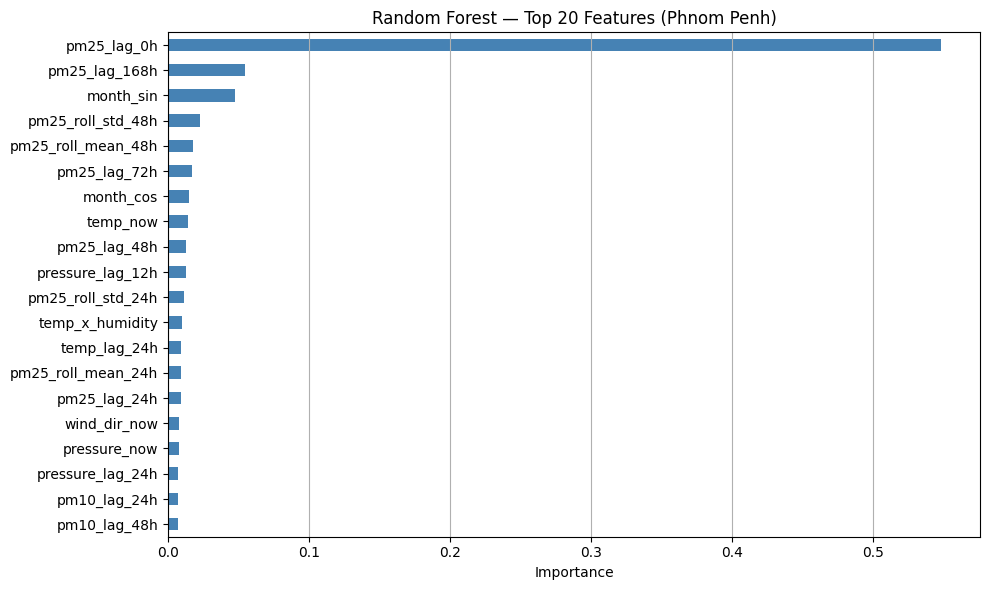

In [12]:
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top20.sort_values().plot(kind="barh", color="steelblue")
plt.title(f"Random Forest — Top 20 Features ({CITY})")
plt.xlabel("Importance")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

## 9. XGBoost

In [23]:
if XGBOOST_AVAILABLE:
    xgb_model = XGBRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        objective="reg:squarederror", eval_metric="rmse",
        early_stopping_rounds=30, random_state=42, n_jobs=-1, verbosity=0
    )
    xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    print(f"Best iteration: {xgb_model.best_iteration}")

    xgb_val_pred  = xgb_model.predict(X_val)
    xgb_test_pred = xgb_model.predict(X_test)

    xgb_val_metrics  = show_metrics("XGBoost — Validation", y_val,  xgb_val_pred)
    xgb_test_metrics = show_metrics("XGBoost — Test",       y_test, xgb_test_pred)

else:
    xgb_val_pred = xgb_test_pred = None
    xgb_val_metrics = xgb_test_metrics = {"RMSE": None, "MAE": None, "MAPE": None, "R2": None}
    print("XGBoost skipped.")

Best iteration: 89

XGBoost — Validation
---------------------------------------------
  RMSE : 7.4588 µg/m³
  MAE  : 5.6592 µg/m³
  MAPE : 56.0430 %
  R²   : 0.0922

XGBoost — Test
---------------------------------------------
  RMSE : 11.3444 µg/m³
  MAE  : 8.8436 µg/m³
  MAPE : 42.5857 %
  R²   : 0.4877


## 10. LSTM (SEQ_LEN = 168 )


In [13]:
if TENSORFLOW_AVAILABLE:
    # Try SEQ_LEN=168 (1 week), fallback to 48 if memory error
    SEQ_LEN = 168

    feature_scaler = StandardScaler()
    target_scaler  = StandardScaler()

    X_tr_sc = feature_scaler.fit_transform(X_train).astype(np.float32)
    X_va_sc = feature_scaler.transform(X_val).astype(np.float32)
    X_te_sc = feature_scaler.transform(X_test).astype(np.float32)

    y_tr_sc = target_scaler.fit_transform(y_train.reshape(-1, 1)).astype(np.float32)
    y_va_sc = target_scaler.transform(y_val.reshape(-1, 1)).astype(np.float32)
    y_te_sc = target_scaler.transform(y_test.reshape(-1, 1)).astype(np.float32)

    def make_sequences(X, y, seq_len):
        Xs = np.lib.stride_tricks.sliding_window_view(X, (seq_len, X.shape[1]))[:, 0]
        ys = y[seq_len - 1:]
        return Xs.astype(np.float32), ys.astype(np.float32)

    # Try building sequences — fallback to smaller SEQ_LEN if MemoryError
    try:
        X_tr_seq, y_tr_seq = make_sequences(X_tr_sc, y_tr_sc.flatten(), SEQ_LEN)
        X_va_seq, y_va_seq = make_sequences(X_va_sc, y_va_sc.flatten(), SEQ_LEN)
        X_te_seq, y_te_seq = make_sequences(X_te_sc, y_te_sc.flatten(), SEQ_LEN)
        print(f"✓ Using SEQ_LEN = {SEQ_LEN} (full week)")
    except MemoryError:
        SEQ_LEN = 48
        print(f"Not enough RAM for 168. Falling back to SEQ_LEN = {SEQ_LEN}")
        X_tr_seq, y_tr_seq = make_sequences(X_tr_sc, y_tr_sc.flatten(), SEQ_LEN)
        X_va_seq, y_va_seq = make_sequences(X_va_sc, y_va_sc.flatten(), SEQ_LEN)
        X_te_seq, y_te_seq = make_sequences(X_te_sc, y_te_sc.flatten(), SEQ_LEN)

    mem_gb = X_tr_seq.nbytes / 1e9
    print(f"Train sequences : {X_tr_seq.shape}")
    print(f"Train RAM       : {mem_gb:.2f} GB")

    tf.random.set_seed(42)
    np.random.seed(42)

    lstm_model = Sequential([
        LSTM(64, input_shape=(SEQ_LEN, X_tr_seq.shape[2]), return_sequences=False),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(16, activation="relu"),
        Dense(1)
    ])
    lstm_model.compile(optimizer="adam", loss="mse")
    lstm_model.summary()

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-6, verbose=1)
    ]

    history = lstm_model.fit(
        X_tr_seq, y_tr_seq,
        validation_data=(X_va_seq, y_va_seq),
        epochs=300, batch_size=128,
        callbacks=callbacks, verbose=1
    )

    lstm_val_pred  = target_scaler.inverse_transform(lstm_model.predict(X_va_seq, verbose=0)).flatten()
    lstm_test_pred = target_scaler.inverse_transform(lstm_model.predict(X_te_seq, verbose=0)).flatten()

    y_val_lstm  = target_scaler.inverse_transform(y_va_seq.reshape(-1, 1)).flatten()
    y_test_lstm = target_scaler.inverse_transform(y_te_seq.reshape(-1, 1)).flatten()

    lstm_val_metrics  = show_metrics("LSTM — Validation", y_val_lstm,  lstm_val_pred)
    lstm_test_metrics = show_metrics("LSTM — Test",        y_test_lstm, lstm_test_pred)

else:
    lstm_val_pred = lstm_test_pred = None
    y_val_lstm = y_val; y_test_lstm = y_test
    lstm_val_metrics = lstm_test_metrics = {"RMSE": None, "MAE": None, "MAPE": None, "R2": None}
    SEQ_LEN = 0
    print("LSTM skipped.")

✓ Using SEQ_LEN = 168 (full week)
Train sequences : (22720, 168, 58)
Train RAM       : 0.89 GB


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        31,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,369 (134.25 KB)

 Trainable params: 34,241 (133.75 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/300
178/178 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - loss: 0.4516 - val_loss: 0.3022 - learning_rate: 0.0010
Epoch 2/300
178/178 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step - loss: 0.3045 - val_loss: 0.2967 - learning_rate: 0.0010
Epoch 3/300
178/178 ━━━━━━━━━━━━━━━━━━━━ 13s 72ms/step - loss: 0.2449 - val_loss: 0.3052 - learning_rate: 0.0010
Epoch 4/300
178/178 ━━━━━━━━━━━━━━━━━━━━ 13s 74ms/step - loss: 0.2074 - val_loss: 0.3151 - learning_rate: 0.0010
Epoch 5/300
178/178 ━━━━━━━━━━━━━━━━━━━━ 12s 70ms/step - loss: 0.1823 - val_loss: 0.3240 - learning_rate: 0.0010
Epoch 6/300
178/178 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - loss: 0.1599 - val_loss: 0.3408 - learning_rate: 0.0010
Epoch 7/300
178/178 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - loss: 0.1461 - val_loss: 0.3439 - learning_rate: 0.0010
Epoch 8/300
178/178 ━━━━━━━━━━━━━━━━━━━━ 13s 75ms/step - loss: 0.1338 - val_loss: 0.3433 - learning_rate: 0.0010
Epoch 9/300
177/178 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.1239
Epoch 9: ReduceLROnPlateau 

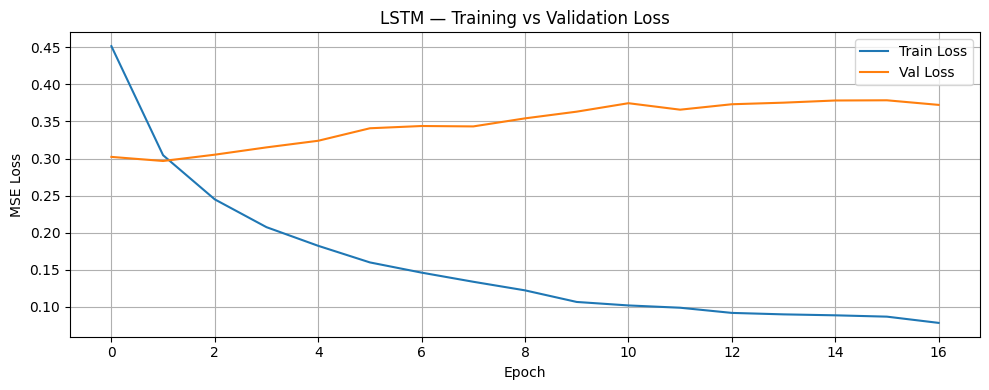

In [14]:

plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"],     label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("LSTM — Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 11. Compare All Models

,Model,RMSE,MAE,MAPE,R2
0,XGBoost,11.3444,8.8436,42.5857,0.4877
1,Random Forest,11.6627,9.0422,44.6790,0.4585
2,LSTM,12.0430,9.4133,46.3190,0.3941


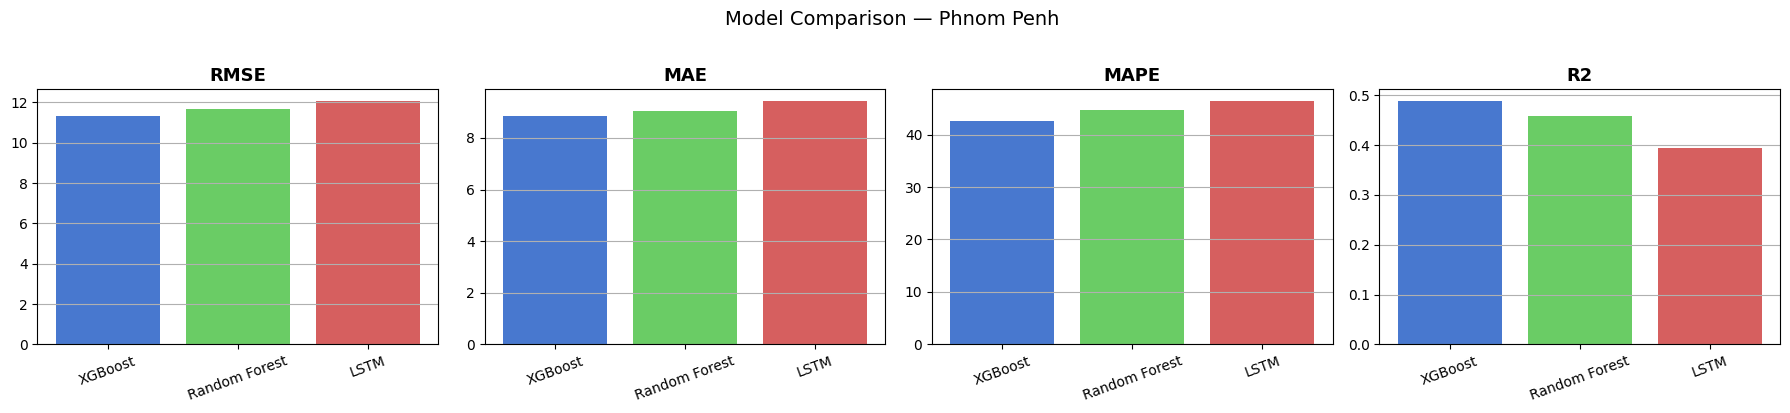

In [24]:
result_rows = [{"Model": "Random Forest", **rf_test_metrics}]

if XGBOOST_AVAILABLE and xgb_test_metrics["RMSE"] is not None:
    result_rows.append({"Model": "XGBoost", **xgb_test_metrics})

if TENSORFLOW_AVAILABLE and lstm_test_metrics["RMSE"] is not None:
    result_rows.append({"Model": "LSTM", **lstm_test_metrics})

results_df = pd.DataFrame(result_rows).sort_values("RMSE").reset_index(drop=True)
display(results_df.round(4))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
colors = ["#4878CF", "#6ACC65", "#D65F5F"][:len(results_df)]
for ax, metric in zip(axes, ["RMSE", "MAE", "MAPE", "R2"]):
    ax.bar(results_df["Model"], results_df[metric], color=colors)
    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y")
plt.suptitle(f"Model Comparison — {CITY} ", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 12. Actual vs Predicted (Test Set)

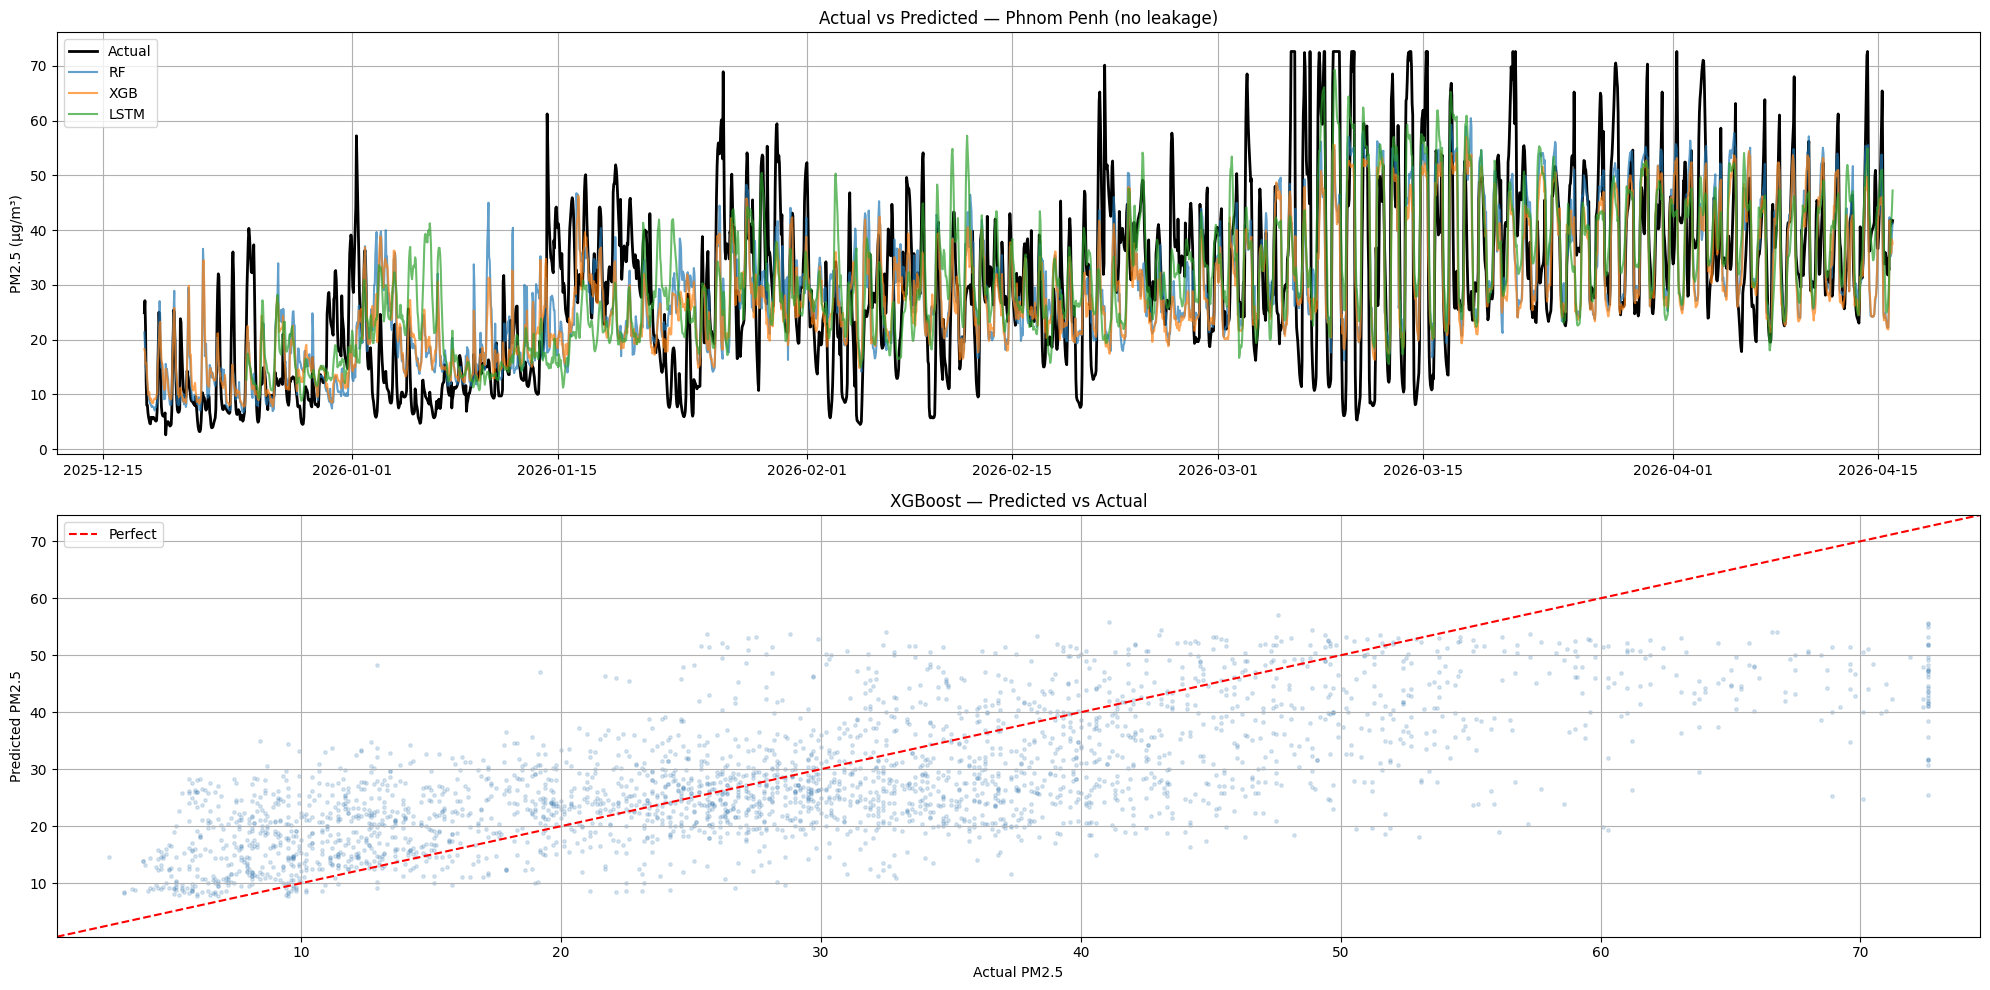

In [25]:
best_name = results_df.iloc[0]["Model"]
if best_name == "Random Forest":
    best_pred = rf_test_pred; best_actual = y_test
elif best_name == "XGBoost":
    best_pred = xgb_test_pred; best_actual = y_test
else:
    best_pred = lstm_test_pred; best_actual = y_test_lstm

fig, axes = plt.subplots(2, 1, figsize=(20, 10))

axes[0].plot(test_df["timestamp"], y_test, label="Actual", linewidth=2, color="black")
axes[0].plot(test_df["timestamp"], rf_test_pred, label="RF", alpha=0.7)
if XGBOOST_AVAILABLE:
    axes[0].plot(test_df["timestamp"], xgb_test_pred, label="XGB", alpha=0.7)
if TENSORFLOW_AVAILABLE and SEQ_LEN > 0:
    axes[0].plot(test_df["timestamp"].values[SEQ_LEN - 1:], lstm_test_pred, label="LSTM", alpha=0.7)
axes[0].set_title(f"Actual vs Predicted — {CITY} (no leakage)")
axes[0].set_ylabel("PM2.5 (µg/m³)")
axes[0].legend()
axes[0].grid(True)

lim = [min(best_actual.min(), best_pred.min()) - 2,
       max(best_actual.max(), best_pred.max()) + 2]
axes[1].scatter(best_actual, best_pred, alpha=0.2, s=6, color="steelblue")
axes[1].plot(lim, lim, "r--", linewidth=1.5, label="Perfect")
axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_title(f"{best_name} — Predicted vs Actual")
axes[1].set_xlabel("Actual PM2.5"); axes[1].set_ylabel("Predicted PM2.5")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

## 13. Error Analysis

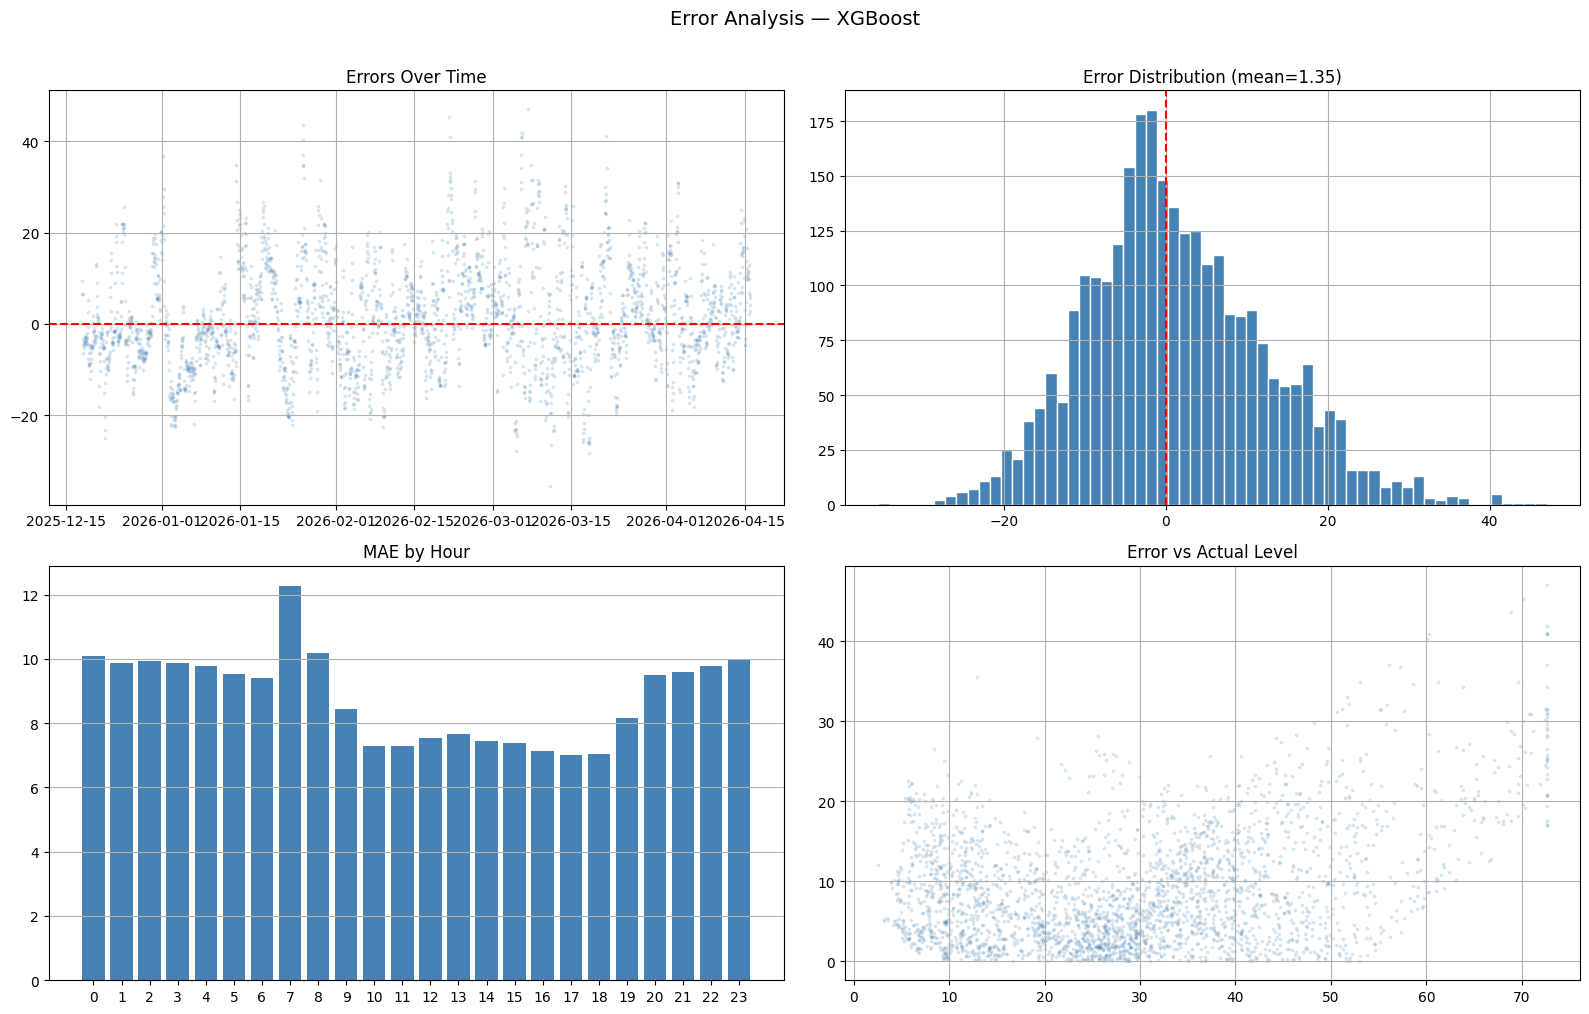

In [26]:
best_name = results_df.iloc[0]["Model"]
if best_name == "Random Forest":
    err_pred = rf_test_pred; err_actual = y_test; err_ts = test_df["timestamp"].values
elif best_name == "XGBoost":
    err_pred = xgb_test_pred; err_actual = y_test; err_ts = test_df["timestamp"].values
else:
    err_pred = lstm_test_pred; err_actual = y_test_lstm; err_ts = test_df["timestamp"].values[SEQ_LEN - 1:]

residuals = err_actual - err_pred

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].scatter(err_ts, residuals, alpha=0.15, s=3, color="steelblue")
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title("Errors Over Time"); axes[0, 0].grid(True)

axes[0, 1].hist(residuals, bins=60, edgecolor="white", color="steelblue")
axes[0, 1].axvline(0, color="red", linestyle="--")
axes[0, 1].set_title(f"Error Distribution (mean={residuals.mean():.2f})"); axes[0, 1].grid(True)

err_hours = pd.to_datetime(err_ts).hour
hour_mae = pd.Series(np.abs(residuals), index=err_hours).groupby(level=0).mean()
axes[1, 0].bar(hour_mae.index, hour_mae.values, color="steelblue")
axes[1, 0].set_title("MAE by Hour"); axes[1, 0].set_xticks(range(24)); axes[1, 0].grid(axis="y")

axes[1, 1].scatter(err_actual, np.abs(residuals), alpha=0.15, s=3, color="steelblue")
axes[1, 1].set_title("Error vs Actual Level"); axes[1, 1].grid(True)

plt.suptitle(f"Error Analysis — {best_name}", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 14. Save Best Model

In [28]:
import joblib

prefix = f"pm25_{CITY.lower().replace(' ', '_')}"
best_model_name = results_df.iloc[0]["Model"]
print("Best model:", best_model_name)

joblib.dump(feature_cols, f"{prefix}_feature_cols.pkl")
joblib.dump(feature_scaler if TENSORFLOW_AVAILABLE else StandardScaler().fit(X_train),
            f"{prefix}_feature_scaler.pkl")

if best_model_name == "Random Forest":
    joblib.dump(rf_model, f"{prefix}_best_model.pkl")
elif best_model_name == "XGBoost":
    joblib.dump(xgb_model, f"{prefix}_best_model.pkl")
else:
    lstm_model.save(f"{prefix}_best_lstm_model.keras")
    joblib.dump(target_scaler, f"{prefix}_target_scaler.pkl")

print(f"\nR² = {results_df.iloc[0]['R2']:.4f}")
print(f"\n Saved for: {CITY}")

Best model: XGBoost

R² = 0.4877

 Saved for: Phnom Penh
